<a href="https://colab.research.google.com/github/kavindus0/Vgurad/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [11]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

paddy_disease_classification_path = kagglehub.competition_download('paddy-disease-classification')

print('Data source import complete.')


Data source import complete.


In [12]:
!pip install -q fastkaggle fastai timm==0.9.16


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 93.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 68.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 105.1 MB/s eta 0:00:00


In [13]:
from fastkaggle import setup_comp
import gc, torch


In [15]:
comp = 'paddy-disease-classification'
path = setup_comp(comp, install='"fastcore>=1.4.5" "fastai>=2.7.1" "timm>=0.6.2.dev0"')
from fastai.vision.all import *
from fastai.losses import LabelSmoothingCrossEntropy


100%|██████████| 1.02G/1.02G [00:03<00:00, 291MB/s]


In [17]:
from fastai.vision.all import *
set_seed(42)


In [18]:
train_path = path/'train_images'
print('class folders:', train_path.ls()[:5])
print('total images :', len(get_image_files(train_path)))

class folders: [Path('paddy-disease-classification/train_images/tungro'), Path('paddy-disease-classification/train_images/brown_spot'), Path('paddy-disease-classification/train_images/hispa'), Path('paddy-disease-classification/train_images/bacterial_leaf_streak'), Path('paddy-disease-classification/train_images/dead_heart')]
total images : 10407


/usr/local/lib/python3.11/dist-packages/timm/models/_factory.py:117: UserWarning: Mapping deprecated model name convnext_small_in22k to current convnext_small.fb_in22k.
  model = create_fn(
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/265M [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()
/usr/local/lib/python3.11/dist-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()


epoch,train_loss,valid_loss,error_rate,time
0,2.418557,1.481151,0.399808,01:14


epoch,train_loss,valid_loss,error_rate,time
0,1.661287,1.252480,0.304661,01:16


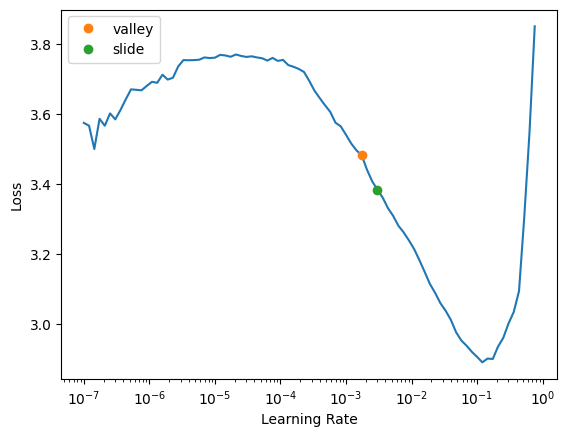

In [19]:
dls = ImageDataLoaders.from_folder(
    train_path, valid_pct=0.2, seed=42,
    item_tfms = Resize(256,  method='pad', pad_mode=PadMode.Zeros),
    batch_tfms= [*aug_transforms(size=128, min_scale=0.75),
                 Normalize.from_stats(*imagenet_stats)],
    bs = 96
)

learn = vision_learner(
          dls, 'convnext_small_in22k',
          metrics=error_rate,
          model_dir=Path('/kaggle/working/models'),
        loss_func = LabelSmoothingCrossEntropy(0.1)

       ).to_fp16()
learn.lr_find(suggest_funcs=(valley, slide))
learn.fine_tune(1, 1e-3)
learn.save('cns_128')
gc.collect(); torch.cuda.empty_cache()

epoch,train_loss,valid_loss,error_rate,time
0,1.415507,1.143783,0.253724,01:52


epoch,train_loss,valid_loss,error_rate,time
0,1.154236,0.939968,0.169149,01:56
1,0.992093,0.818230,0.110524,01:57
2,0.892836,0.767170,0.086016,01:56
3,0.842033,0.756873,0.078808,01:54


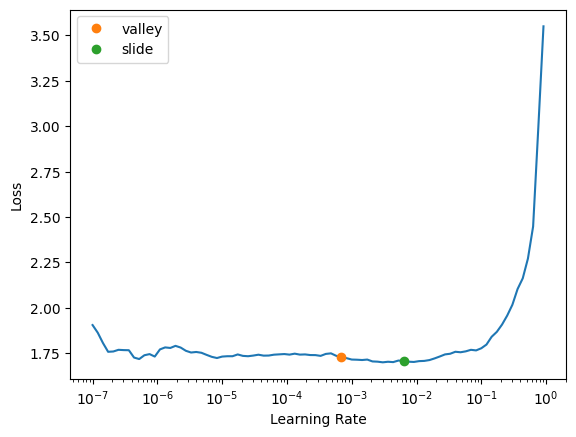

In [20]:
dls = ImageDataLoaders.from_folder(
    train_path, valid_pct=0.2, seed=42,
    item_tfms = Resize(448, method='pad', pad_mode=PadMode.Zeros),
    batch_tfms= [*aug_transforms(size=224, min_scale=0.75),
                 Normalize.from_stats(*imagenet_stats)],
    bs = 64
)

learn.dls = dls
learn.load('cns_128', weights_only=False)
learn.freeze()
learn.lr_find(suggest_funcs=(valley, slide))
learn.fine_tune(4, 1.5e-3)
learn.save('cns_224')
gc.collect(); torch.cuda.empty_cache()

/usr/local/lib/python3.11/dist-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()
/usr/local/lib/python3.11/dist-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()


epoch,train_loss,valid_loss,error_rate,time


epoch,train_loss,valid_loss,error_rate,time
0,0.884275,0.766769,0.078328,02:12
1,0.806384,0.702244,0.049495,02:14
2,0.747720,0.680121,0.042287,02:13


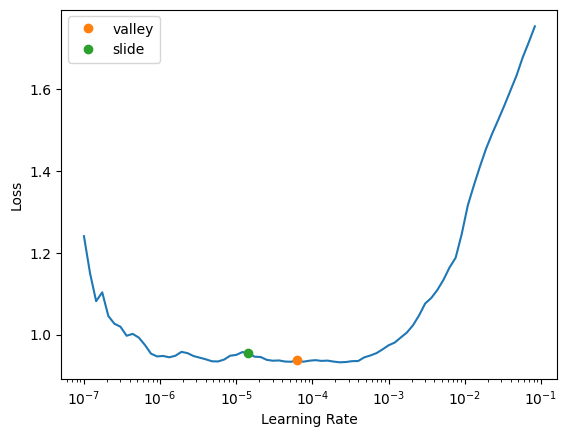

In [22]:
dls = ImageDataLoaders.from_folder(
    train_path, valid_pct=0.2, seed=42,
    item_tfms = Resize((480, 360),
                       method='pad', pad_mode=PadMode.Zeros),
    batch_tfms= [*aug_transforms(size=(320,240), min_scale=0.75),
                 Normalize.from_stats(*imagenet_stats)],
    bs = 40
)

learn.dls = dls
learn.load('cns_224', weights_only=False)
learn.unfreeze()
learn.lr_find(suggest_funcs=(valley, slide))
learn.fit_one_cycle(3, 5e-5)
learn.save('cns_320')
gc.collect(); torch.cuda.empty_cache()

/usr/local/lib/python3.11/dist-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()
/usr/local/lib/python3.11/dist-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()


epoch,train_loss,valid_loss,error_rate,time
0,0.804762,0.702364,0.051418,04:13
1,0.761401,0.689458,0.050937,04:12
2,0.764743,0.684464,0.046132,04:12
3,0.752677,0.680340,0.041807,04:12
4,0.708985,0.659527,0.029793,04:12
5,0.711279,0.650194,0.030754,04:12
6,0.700086,0.647930,0.028832,04:12
7,0.701109,0.650183,0.028352,04:12
8,0.686569,0.646993,0.028832,04:12
9,0.695345,0.645060,0.027391,04:12


Path('/kaggle/working/models/cns_480.pth')

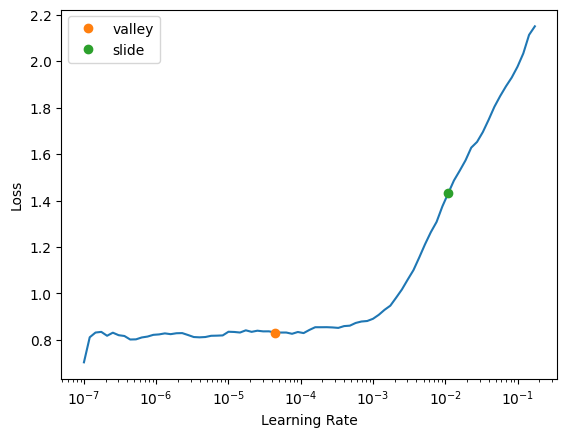

In [24]:
dls = ImageDataLoaders.from_folder(
    train_path, valid_pct=0.2, seed=42,
    item_tfms = Resize((480,360), method='pad', pad_mode=PadMode.Zeros),
    batch_tfms= [*aug_transforms(size=(480,360), min_scale=0.75),
                 Normalize.from_stats(*imagenet_stats)],
    bs = 24
)

learn.dls = dls
learn.load('cns_320', weights_only=False)
learn.unfreeze()
learn.lr_find(suggest_funcs=(valley, slide))
learn.fit_one_cycle(10, 1e-5)
learn.save('cns_480')

In [25]:
tta_preds,targs = learn.tta(dl=learn.dls.valid)
error_rate(tta_preds, targs)

/usr/local/lib/python3.11/dist-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()
/usr/local/lib/python3.11/dist-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()


TensorBase(0.0279)

In [26]:
from fastai.vision.all import get_image_files
import pandas as pd, numpy as np

tst_files = get_image_files(path/'test_images').sorted()
tst_dl    = learn.dls.test_dl(tst_files)

tta_preds, _ = learn.tta(dl=tst_dl)

idxs = tta_preds.argmax(dim=1).cpu().numpy()

vocab  = np.array(learn.dls.vocab)
labels = vocab[idxs]

ss = pd.read_csv(path/'sample_submission.csv')
ss['label'] = labels

ss.to_csv('submission.csv', index=False)

print(ss.head())

     image_id   label
0  200001.jpg   hispa
1  200002.jpg  normal
2  200003.jpg   blast
3  200004.jpg   blast
4  200005.jpg   blast


In [43]:
learn.tta(dl=tst_dl)
learn.export('paddy_model.pkl')

/usr/local/lib/python3.11/dist-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()
/usr/local/lib/python3.11/dist-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()


In [44]:
learn.export('/content/paddy_model.pkl')

In [42]:
!ls models

ls: cannot access 'models': No such file or directory
